# Regional Pacific sea-surface temperature

Regional counterpart of `National/sea_surface_temperature/a_Mean_Temperature_maps.ipynb`. The maps cover the tropical/subtropical Pacific and overlay every EEZ boundary in `data/regional/Pacific_EEZs`.

The notebook presents regional SST trends and DJF anomalies using reproducibly sourced observational data.

In [1]:
# CIndRA notebook display standard
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.dpi': 100,
    'savefig.dpi': 300,
})

In [2]:
from pathlib import Path
import sys
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np

root_candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
repo_root = next((p for p in root_candidates if (p / 'functions' / 'sst.py').is_file()), None)
if repo_root is None:
    raise FileNotFoundError('Could not locate the CIndRA repository root.')
sys.path.insert(0, str(repo_root / 'functions'))

from sst import (
    compute_djf_period_anomalies,
    compute_sst_trend,
    load_pacific_sst,
    plot_pacific_sst_field,
    plot_pacific_sst_panels,
)

## 1. Configuration

The NOAA OISST monthly-mean NetCDF is downloaded directly by this notebook and cached under `data/sea_surface_temperature/`.

In [3]:
data_dir = repo_root / 'data'
fig_dir = repo_root / 'matrix_cc' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

sst_url = 'https://downloads.psl.noaa.gov/Datasets/noaa.oisst.v2/sst.mnmean.nc'
sst_file = data_dir / 'sea_surface_temperature' / 'sst.mnmean.nc'
force_download = False
eez_file = data_dir / 'regional' / 'Pacific_EEZs' / 'Pacific_EEZs.shp'
dataset_id = 'sst'
pacific_extent = (125, 245, -35, 35)  # 125°E–115°W, 35°S–35°N
trend_period = (1982, 2020)
reference_period = (1981, 2020)
period_starts = range(1985, 2020, 5)
period_years = 5

### Download NOAA OISST

The download is approximately 61 MB. It is skipped when the cached file already exists; set `force_download = True` above to refresh it.

In [4]:
sst_file.parent.mkdir(parents=True, exist_ok=True)
if force_download or not sst_file.is_file():
    temporary_file = sst_file.with_suffix(sst_file.suffix + '.part')
    print(f'Downloading NOAA OISST to {sst_file} ...')
    urlretrieve(sst_url, temporary_file)
    temporary_file.replace(sst_file)
    print(f'Download complete ({sst_file.stat().st_size / 1024**2:.1f} MB).')
else:
    print(f'Using cached NOAA OISST: {sst_file} ({sst_file.stat().st_size / 1024**2:.1f} MB).')

Using cached NOAA OISST: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/CIndRA/data/sea_surface_temperature/sst.mnmean.nc (61.1 MB).


## 2. Load the regional SST field and Pacific EEZs

In [5]:
pacific = load_pacific_sst(sst_file, eez_file, dataset_id, pacific_extent)
data = pacific.data
print(
    f'{len(pacific.eez)} EEZ polygons; '
    f'{data.sizes["lon"]} × {data.sizes["lat"]} SST grid; '
    f'{str(data.time.min().values)[:10]} to {str(data.time.max().values)[:10]}'
)

29 EEZ polygons; 120 × 70 SST grid; 1981-12-01 to 2023-01-01


## 3. Regional mean SST

Long-term mean SST across the full Pacific domain, with all EEZ boundaries overlaid.

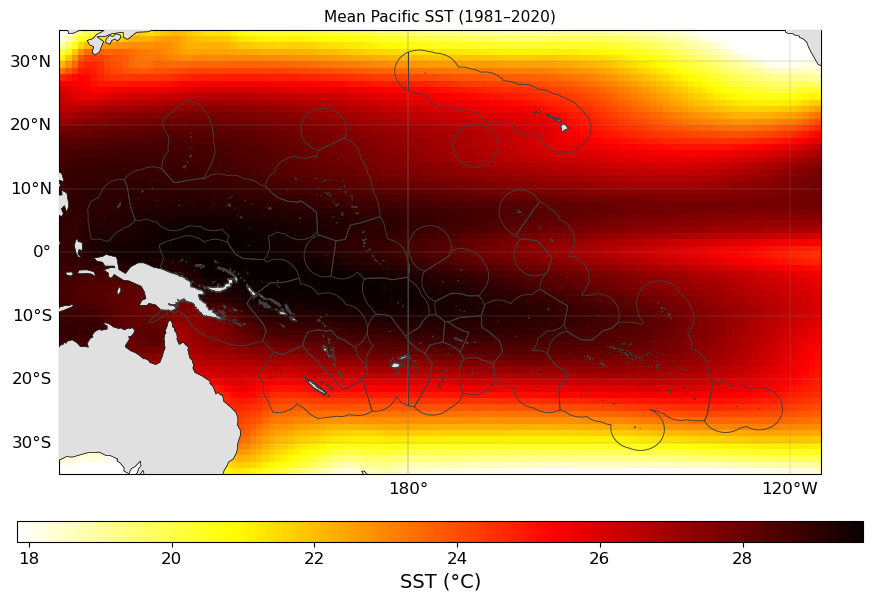

In [6]:
sst_mean = data[dataset_id].sel(time=slice(str(reference_period[0]), str(reference_period[1]))).mean('time')
mean_vmin, mean_vmax = np.nanpercentile(sst_mean, [1, 99])
fig_mean, ax_mean = plot_pacific_sst_field(
    sst_mean, pacific,
    f'Mean Pacific SST ({reference_period[0]}–{reference_period[1]})',
    cmap='hot_r', vmin=mean_vmin, vmax=mean_vmax,
    filename=fig_dir / 'SST_regional_mean.png',
)
plt.show()

## 4. SST trends — Figure 19

Linear trend of annual mean SST at every grid cell, expressed in °C per decade. The fixed −0.10 to 0.30 °C/decade scale matches the range used in Figure 19.

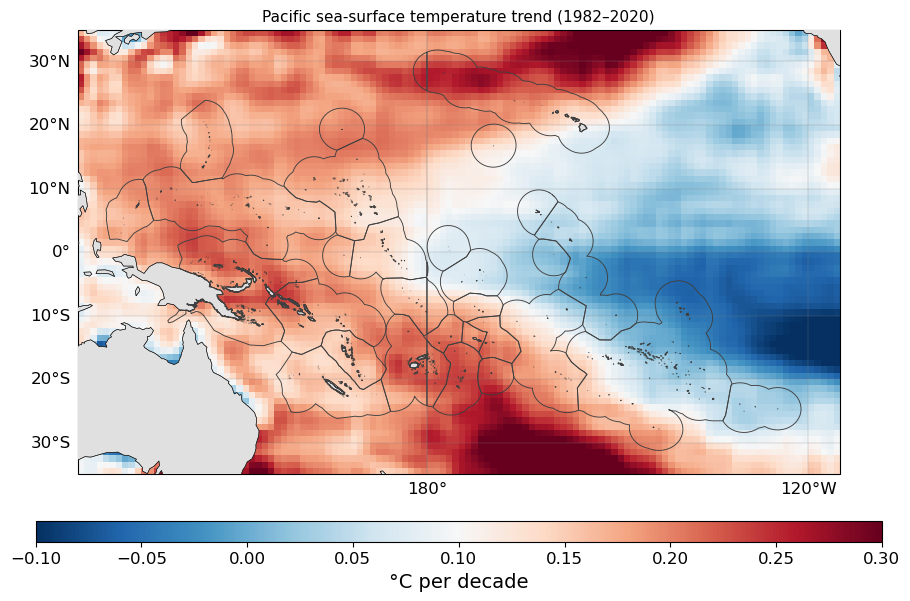

In [7]:
sst_trend = compute_sst_trend(data, dataset_id, trend_period)
fig_19, ax_19 = plot_pacific_sst_field(
    sst_trend, pacific,
    f'Pacific sea-surface temperature trend ({trend_period[0]}–{trend_period[1]})',
    cmap='RdBu_r', vmin=-0.10, vmax=0.30, label='°C per decade',
    filename=fig_dir / 'F19_SST_regional_trend.png',
)
plt.show()

## 5. Boreal-winter SST anomalies — Figure 20

Mean December–February (DJF) SST anomalies in consecutive five-year blocks from `1985–1990` through `2015–2020`. Labels use half-open intervals, so every panel contains exactly five winters. Anomalies are departures from the 1981–2020 DJF climatology.

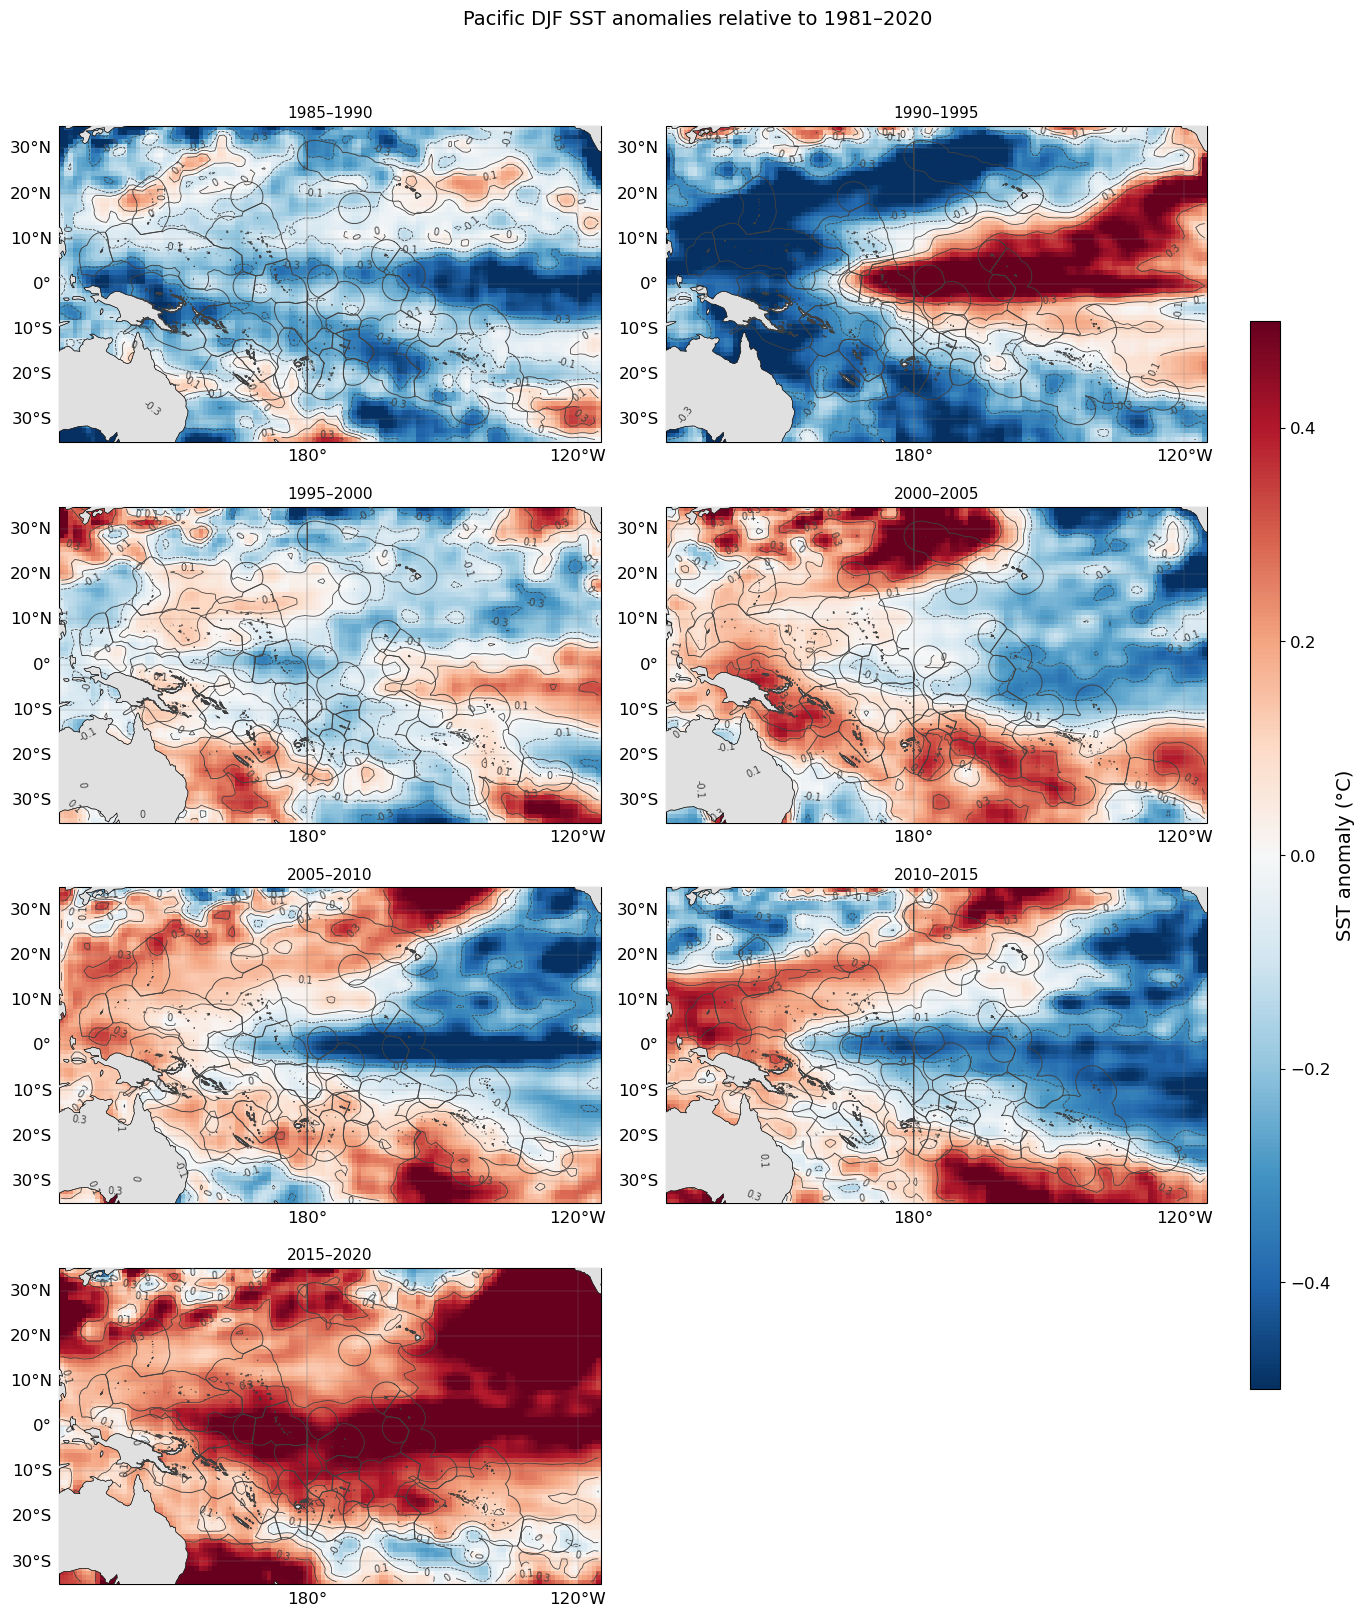

In [8]:
djf_anomalies = compute_djf_period_anomalies(
    data, dataset_id, period_starts, period_years, reference_period,
)
fig_20 = plot_pacific_sst_panels(
    djf_anomalies, pacific,
    f'Pacific DJF SST anomalies relative to {reference_period[0]}–{reference_period[1]}',
    dim='period', cmap='RdBu_r', vmin=-0.5, vmax=0.5,
    label='SST anomaly (°C)', ncols=2,
    filename=fig_dir / 'F20_SST_DJF_5year_anomalies.png',
)
plt.show()

## Interpretation and reproducibility notes

- Regional aggregates can hide local differences among stations, grid cells and EEZs.
- Gridded SST resolution, data gaps and the selected climatological baseline affect anomalies, extremes and marine-heatwave metrics.
- Linear trends are descriptive unless the notebook explicitly accounts for temporal autocorrelation and other statistical assumptions.
- Confirm the printed source, analysis period, reference period and output paths before using figures or tables in reporting.